# Demo Notebook to compare Obs-ML Timeseries

In [31]:
from pathlib import Path
import sys
import importlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(
    r"D:\Workplace\ECMWF Code for Earth Challenge\Coding Phase\TriHydrA"
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.trihydra.layer2.signature_comparison as sigcomp
importlib.reload(sigcomp)

from src.trihydra.layer2.signature_comparison import (
    prepare_obs_ml_series,
    fill_obs_for_layer2,
    calculate_layer2_profiles,
    extract_signature_profile,
    compare_signature_profiles,
)

print("Layer 2 functions imported.")

Layer 2 functions imported.


In [33]:
## Load Basin Data

basin_id = "GRDC_5304140"

csv_path = PROJECT_ROOT / "data" / f"{basin_id}_streamflow_data.csv"

df = pd.read_csv(csv_path)

print("Loaded:", csv_path)
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Loaded: D:\Workplace\ECMWF Code for Earth Challenge\Coding Phase\TriHydrA\data\GRDC_5304140_streamflow_data.csv
Shape: (16063, 8)

Columns:
['Date', 'Station_ID', 'Basin_role', 'Area_km2', 'Observed_mm_day', 'Simulated_mm_day', 'Observed_m3s', 'Simulated_m3s']


In [35]:
#Specifying the columns I intend to use

date_col = "Date"
obs_col = "Observed_m3s"
ml_col = "Simulated_m3s"

df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(date_col)

obs_series = pd.Series(
    df[obs_col].values,
    index=df[date_col],
    name="obs",
)

ml_series = pd.Series(
    df[ml_col].values,
    index=df[date_col],
    name="ml",
)

# print("OBS series:")
# print(obs_series.head())
# print(obs_series.tail())

# print("\nML series:")
# print(ml_series.head())
# print(ml_series.tail())

In [37]:
obs_aligned, ml_aligned = prepare_obs_ml_series(
    obs_series=obs_series,
    ml_series=ml_series,
)

print("Aligned OBS period:", obs_aligned.index.min(), "to", obs_aligned.index.max())
print("Aligned ML period:", ml_aligned.index.min(), "to", ml_aligned.index.max())

print("\nAligned length:")
print("OBS:", len(obs_aligned))
print("ML:", len(ml_aligned))

print("\nMissing values:")
print("OBS missing:", obs_aligned.isna().sum())
print("ML missing:", ml_aligned.isna().sum())

pd.DataFrame({
    "obs_aligned": obs_aligned,
    "ml_aligned": ml_aligned,
}).head()

Aligned OBS period: 1980-01-10 00:00:00 to 2023-05-02 00:00:00
Aligned ML period: 1980-01-10 00:00:00 to 2023-05-02 00:00:00

Aligned length:
OBS: 15819
ML: 15819

Missing values:
OBS missing: 351
ML missing: 0


,obs_aligned,ml_aligned
Date,,
1980-01-10,26.187037,103.636340
1980-01-11,26.187037,104.837890
1980-01-12,26.187037,105.326450
1980-01-13,26.187037,97.668655
1980-01-14,26.187037,102.376396


OBS length: 15819
OBS missing: 351
OBS missing ratio: 2.22 %


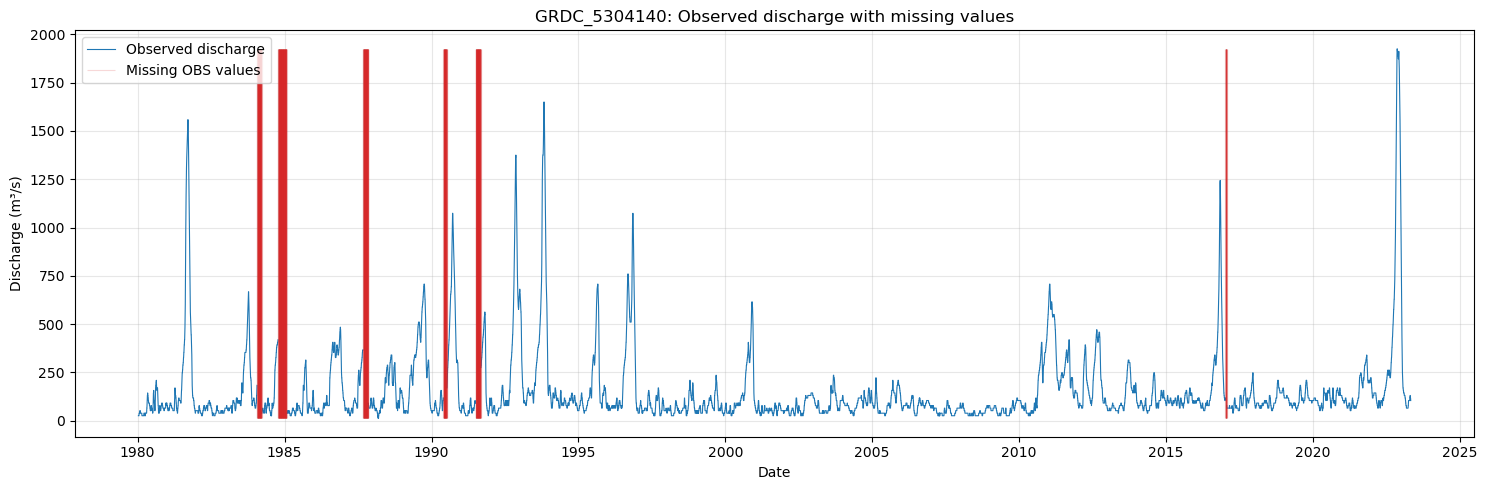

In [39]:
#OBS raw hydrograph with missing values highlighted

obs_raw = obs_aligned.copy()

missing_mask = obs_raw.isna()
missing_dates = obs_raw[missing_mask].index

print("OBS length:", len(obs_raw))
print("OBS missing:", missing_mask.sum())
print("OBS missing ratio:", round(missing_mask.mean() * 100, 2), "%")

plt.figure(figsize=(15, 5))

plt.plot(
    obs_raw.index,
    obs_raw,
    label="Observed discharge",
    linewidth=0.8,
    color="#1f77b4",
)

# Show missing positions as vertical red lines
if len(missing_dates) > 0:
    ymin = obs_raw.min(skipna=True)
    ymax = obs_raw.max(skipna=True)
    plt.vlines(
        missing_dates,
        ymin=ymin,
        ymax=ymax,
        color="#d62728",
        alpha=0.18,
        linewidth=0.8,
        label="Missing OBS values",
    )

plt.title(f"{basin_id}: Observed discharge with missing values")
plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
# Temporary OBS filling
obs_l2 = fill_obs_for_layer2(
    obs_aligned=obs_aligned,
    method="seasonal_climatology",
    window_days=15,
    min_samples=5,
)

print("Raw OBS missing:", obs_aligned.isna().sum())
print("Layer 2 OBS missing after seasonal filling:", obs_l2.isna().sum())
print("Filled values:", (obs_aligned.isna() & obs_l2.notna()).sum())

Raw OBS missing: 351
Layer 2 OBS missing after seasonal filling: 0
Filled values: 351


In [41]:
fill_check = pd.DataFrame({
    "obs_raw": obs_aligned,
    "obs_l2_seasonal_filled": obs_l2,
    "ml_raw": ml_aligned,
})

fill_check["was_filled"] = (
    fill_check["obs_raw"].isna()
    & fill_check["obs_l2_seasonal_filled"].notna()
)

fill_check[fill_check["was_filled"]].head(20)

,obs_raw,obs_l2_seasonal_filled,ml_raw,was_filled
Date,,,,
1984-01-25,NaN,78.561104,138.51414,True
1984-01-26,NaN,65.467590,155.22888,True
1984-01-27,NaN,65.467590,166.69770,True
1984-01-28,NaN,65.467590,158.64578,True
1984-01-29,NaN,65.467590,169.83394,True
1984-01-30,NaN,65.467590,175.02055,True
1984-01-31,NaN,65.467590,174.93205,True
1984-02-01,NaN,65.467590,173.05807,True
1984-02-02,NaN,65.467590,169.21115,True


Number of filled values: 351


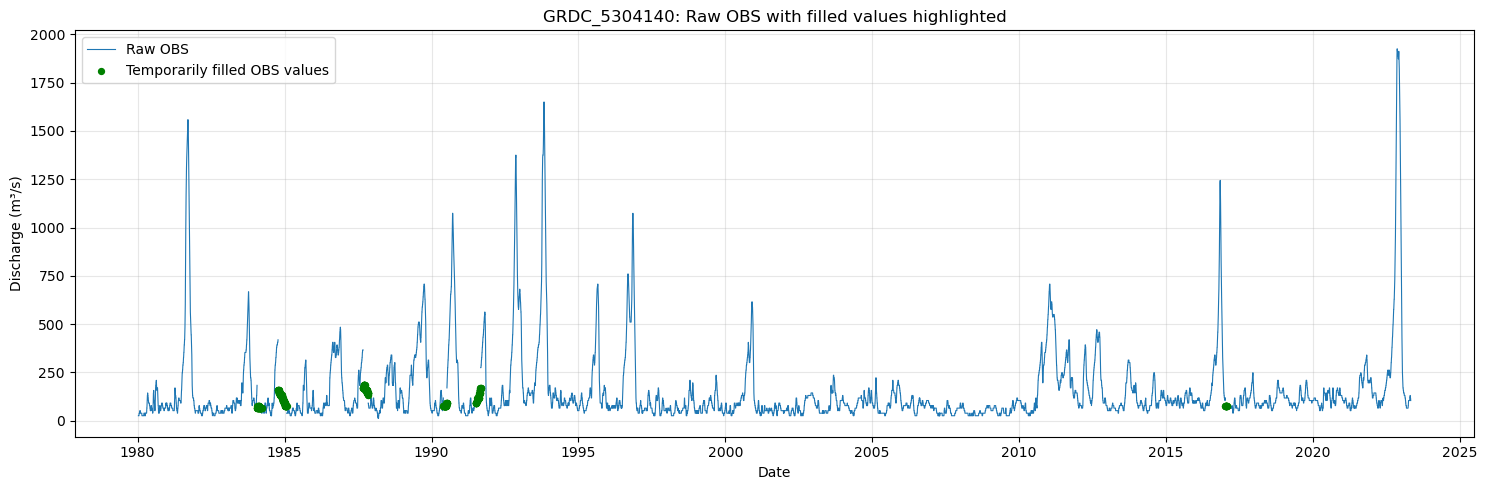

In [43]:
filled_mask = obs_aligned.isna() & obs_l2.notna()
filled_dates = obs_l2.index[filled_mask]
filled_values = obs_l2[filled_mask]

print("Number of filled values:", filled_mask.sum())

plt.figure(figsize=(15, 5))

# Raw OBS hydrograph
plt.plot(
    obs_aligned.index,
    obs_aligned,
    label="Raw OBS",
    linewidth=0.8,
    color="#1f77b4",
)

# Filled values only, shown in green
plt.scatter(
    filled_dates,
    filled_values,
    label="Temporarily filled OBS values",
    color="green",
    s=18,
    zorder=3,
)

plt.title(f"{basin_id}: Raw OBS with filled values highlighted")
plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

            OBS imputed for Layer 2          ML
Date                                           
1980-01-10                26.187037  103.636340
1980-01-11                26.187037  104.837890
1980-01-12                26.187037  105.326450
1980-01-13                26.187037   97.668655
1980-01-14                26.187037  102.376396
            OBS imputed for Layer 2         ML
Date                                          
2023-04-28                117.84182  157.66087
2023-04-29                117.84182  148.29955
2023-04-30                117.84182  152.66312
2023-05-01                104.74830  137.27840
2023-05-02                104.74830  138.23053

Missing values:
OBS imputed for Layer 2    0
ML                         0
dtype: int64


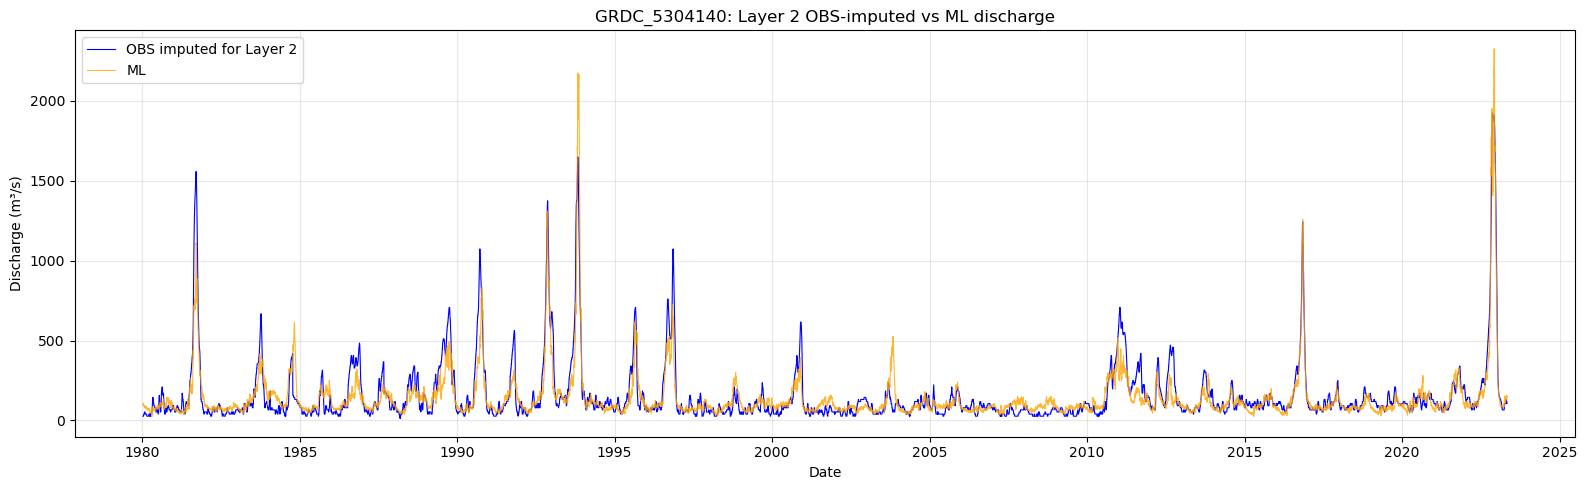

In [44]:
plot_df = pd.DataFrame({
    "OBS imputed for Layer 2": obs_l2,
    "ML": ml_aligned,
})

print(plot_df.head())
print(plot_df.tail())

print("\nMissing values:")
print(plot_df.isna().sum())

plt.figure(figsize=(16, 5))

plt.plot(
    plot_df.index,
    plot_df["OBS imputed for Layer 2"],
    label="OBS imputed for Layer 2",
    linewidth=0.8,
    color="blue",
)

plt.plot(
    plot_df.index,
    plot_df["ML"],
    label="ML",
    linewidth=0.8,
    color="orange",
    alpha=0.8,
)

plt.title(f"{basin_id}: Layer 2 OBS-imputed vs ML discharge")
plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [45]:
profiles = calculate_layer2_profiles(
    obs_l2=obs_l2,
    ml_aligned=ml_aligned,
)

obs_signature_profile = extract_signature_profile(
    summary_profile=profiles["obs_summary"],
    monthly_profile=profiles["obs_monthly"],
    yearly_profile=profiles["obs_yearly"],
)

ml_signature_profile = extract_signature_profile(
    summary_profile=profiles["ml_summary"],
    monthly_profile=profiles["ml_monthly"],
    yearly_profile=profiles["ml_yearly"],
)

signature_check = pd.DataFrame([
    {"series": "obs", **obs_signature_profile},
    {"series": "ml", **ml_signature_profile},
])

signature_check

'''
The typical wettest month median flow is about seasonality_index times the typical driest month median flow.
'''

'\nThe typical wettest month median flow is about seasonality_index times the typical driest month median flow.\n'

In [46]:
import calendar

def inspect_monthly_seasonal_cycle(monthly_profile, label):
    monthly = monthly_profile.copy()

    monthly["month"] = pd.to_datetime(monthly["month_end"]).dt.month

    monthly_seasonal_cycle = (
        monthly
        .dropna(subset=["median"])
        .groupby("month")["median"]
        .median()
    )

    out = monthly_seasonal_cycle.reset_index()
    out.columns = ["month", "typical_monthly_median_flow"]
    out["month_name"] = out["month"].apply(lambda x: calendar.month_abbr[int(x)])

    wettest_month = int(monthly_seasonal_cycle.idxmax())
    driest_month = int(monthly_seasonal_cycle.idxmin())

    seasonality_index = (
        monthly_seasonal_cycle.max()
        / monthly_seasonal_cycle.min()
    )

    print(label)
    print("Wettest month:", wettest_month, calendar.month_name[wettest_month])
    print("Driest month:", driest_month, calendar.month_name[driest_month])
    print("Seasonality index:", seasonality_index)

    return out

In [47]:
obs_monthly_cycle = inspect_monthly_seasonal_cycle(
    profiles["obs_monthly"],
    label="OBS monthly seasonal cycle",
)

ml_monthly_cycle = inspect_monthly_seasonal_cycle(
    profiles["ml_monthly"],
    label="ML monthly seasonal cycle",
)

display(obs_monthly_cycle)
display(ml_monthly_cycle)

OBS monthly seasonal cycle
Wettest month: 9 September
Driest month: 3 March
Seasonality index: 3.3333358508357094
ML monthly seasonal cycle
Wettest month: 11 November
Driest month: 4 April
Seasonality index: 2.25735122868421


,month,typical_monthly_median_flow,month_name
0,1,78.561104,Jan
1,2,65.467590,Feb
2,3,58.920832,Mar
3,4,65.467590,Apr
4,5,78.561104,May
5,6,78.561104,Jun
6,7,104.748300,Jul
7,8,130.935330,Aug
8,9,196.402920,Sep
9,10,157.122380,Oct


,month,typical_monthly_median_flow,month_name
0,1,84.411795,Jan
1,2,69.229677,Feb
2,3,67.163705,Mar
3,4,66.997941,Apr
4,5,76.629765,May
5,6,89.275625,Jun
6,7,105.048610,Jul
7,8,148.249280,Aug
8,9,148.564970,Sep
9,10,138.029170,Oct


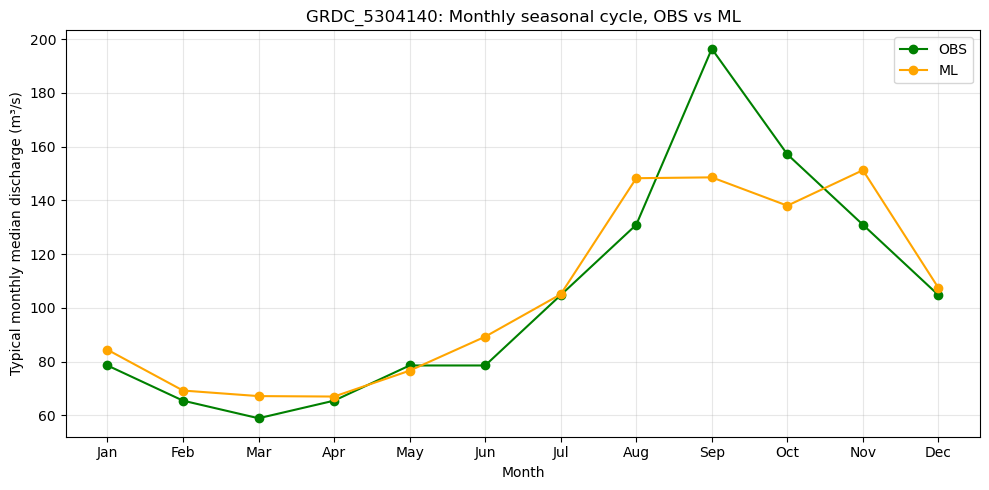

In [48]:
obs_plot = obs_monthly_cycle.copy()
ml_plot = ml_monthly_cycle.copy()

monthly_cycle_plot = pd.DataFrame({
    "month": obs_plot["month"],
    "month_name": obs_plot["month_name"],
    "OBS": obs_plot["typical_monthly_median_flow"],
    "ML": ml_plot["typical_monthly_median_flow"],
})

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_cycle_plot["month_name"],
    monthly_cycle_plot["OBS"],
    marker="o",
    label="OBS",
    color="green",
)

plt.plot(
    monthly_cycle_plot["month_name"],
    monthly_cycle_plot["ML"],
    marker="o",
    label="ML",
    color="orange",
)

plt.title(f"{basin_id}: Monthly seasonal cycle, OBS vs ML")
plt.xlabel("Month")
plt.ylabel("Typical monthly median discharge (m³/s)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [63]:
profiles = calculate_layer2_profiles(
    obs_l2=obs_l2,
    ml_aligned=ml_aligned,
)

obs_signature_profile = extract_signature_profile(
    summary_profile=profiles["obs_summary"],
    monthly_profile=profiles["obs_monthly"],
    yearly_profile=profiles["obs_yearly"],
)

ml_signature_profile = extract_signature_profile(
    summary_profile=profiles["ml_summary"],
    monthly_profile=profiles["ml_monthly"],
    yearly_profile=profiles["ml_yearly"],
)

comparison_table = compare_signature_profiles(
    basin_id=basin_id,
    obs_signature_profile=obs_signature_profile,
    ml_signature_profile=ml_signature_profile,
)

comparison_table

,basin_id,signature,obs_value,ml_value,difference,relative_difference_percent,diagnostic,flag
0,GRDC_5304140,low_flow_q05,39.280710,52.574769,13.294059,33.843733,ML overestimates low-flow/baseflow behaviour,True
1,GRDC_5304140,high_flow_q95,523.741150,364.987281,-158.753869,-30.311513,ML underestimates high-flow behaviour,True
2,GRDC_5304140,zero_ratio,0.000000,0.000000,0.000000,NaN,ML matches OBS zero-flow behaviour,False
3,GRDC_5304140,annual_max_median,314.244750,286.348310,-27.896440,-8.877297,ML underestimates annual extremes,True
4,GRDC_5304140,seasonality_index,3.333336,2.257351,-1.075985,-32.279514,ML smooths wet/dry seasonal contrast,True
5,GRDC_5304140,wettest_month,9.000000,11.000000,2.000000,22.222222,ML wettest month differs from OBS,True
6,GRDC_5304140,driest_month,3.000000,4.000000,1.000000,33.333333,ML driest month differs from OBS,True
